# Telco Churn — SageMaker Training, HPO, Evaluation & Batch Inference

Continues from `telco_churn_preprocessing.ipynb`, reading `train_clean.csv`, `val_clean.csv` and
`test_clean.csv` **directly from S3**. Nothing is written to local disk: the splits are streamed into
pandas, re-laid out in memory, and PUT back to S3 in the format the algorithm expects. Set
`SOURCE_BUCKET` / `SOURCE_PREFIX` in Section 1 to wherever your preprocessing step uploaded them.

**Steps covered:** (4) built-in XGBoost training + hyperparameter tuning, (5) evaluation with
F1 / ROC-AUC / precision / recall + confusion matrix, (6) cost-sensitive threshold selection and
Batch Transform inference on unseen data.

> **Critical format rule:** SageMaker's built-in XGBoost expects CSV with the **target in the first
> column and no header row**. The preprocessing notebook wrote `Churn` last *with* a header, so
> Section 1 re-lays out the files. Skipping this silently trains on the wrong target column.

## 1. Session Setup and Data Formatting

In [1]:
# One-time: install plotting + metrics libs into THIS kernel, then re-run the import cell above.
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "matplotlib", "scikit-learn"])

CompletedProcess(args=['/home/ec2-user/anaconda3/envs/python3/bin/python', '-m', 'pip', 'install', '-q', 'matplotlib', 'scikit-learn'], returncode=0)

In [2]:
# Import SageMaker SDK, AWS helpers, and the metrics/plotting libraries used for evaluation.
import boto3, sagemaker, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sagemaker.inputs import TrainingInput
from sagemaker.tuner import HyperparameterTuner, IntegerParameter, ContinuousParameter
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
pd.set_option("display.max_columns", None)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


In [3]:
# Open a SageMaker session and resolve the execution role, region, and S3 bucket/prefix for artifacts.
sess   = sagemaker.Session()
region = sess.boto_region_name
bucket = "churn-prediction-ak"           # or replace with your own bucket name
try:
    role = sagemaker.get_execution_role()          # works inside Studio / notebook instances
except Exception:
    role = "arn:aws:iam::<ACCOUNT_ID>:role/<SageMakerExecutionRole>"   # paste your role ARN if running locally
print(f"region={region}\nbucket={bucket}\nrole={role}")

region=eu-west-1
bucket=churn-prediction-ak
role=arn:aws:iam::481719141347:role/service-role/AmazonSageMaker-ExecutionRole-20260817T050781


In [4]:
# Point at the S3 location where the preprocessing notebook saved the three splits, and confirm they exist.
SOURCE_BUCKET = "churn-prediction-ak"                     # <-- change if your data lives in a different bucket
SOURCE_PREFIX = "data"    # <-- folder holding train_clean.csv / val_clean.csv / test_clean.csv
s3 = boto3.client("s3")
listing = s3.list_objects_v2(Bucket=SOURCE_BUCKET, Prefix=SOURCE_PREFIX).get("Contents", [])
for o in listing:
    print(f"{o['Size']:>10,} B   s3://{SOURCE_BUCKET}/{o['Key']}")
assert listing, f"Nothing under s3://{SOURCE_BUCKET}/{SOURCE_PREFIX} - check the bucket, prefix, and that you are in the right region"

         0 B   s3://churn-prediction-ak/data/
   103,474 B   s3://churn-prediction-ak/data/processed/batch_input.csv
   492,228 B   s3://churn-prediction-ak/data/processed/train.csv
   103,405 B   s3://churn-prediction-ak/data/processed/val_features.csv
   105,517 B   s3://churn-prediction-ak/data/processed/validation.csv
   107,869 B   s3://churn-prediction-ak/data/test_clean.csv
   501,292 B   s3://churn-prediction-ak/data/train_clean.csv
   107,845 B   s3://churn-prediction-ak/data/val_clean.csv


In [5]:
# Stream the three splits from S3 straight into pandas - no local copy, no s3fs dependency.
def read_s3_csv(key, bkt=None):
    obj = s3.get_object(Bucket=bkt or SOURCE_BUCKET, Key=key)
    return pd.read_csv(obj["Body"])

train = read_s3_csv(f"{SOURCE_PREFIX}/train_clean.csv")
val   = read_s3_csv(f"{SOURCE_PREFIX}/val_clean.csv")
test  = read_s3_csv(f"{SOURCE_PREFIX}/test_clean.csv")
print(f"train {train.shape} | val {val.shape} | test {test.shape}")
print(f"churn rate -> train {train.Churn.mean():.3f}  val {val.Churn.mean():.3f}  test {test.Churn.mean():.3f}")

train (4930, 24) | val (1056, 24) | test (1057, 24)
churn rate -> train 0.265  val 0.265  test 0.266


In [6]:
# Move Churn to the first column - the layout the built-in XGBoost algorithm requires.
FEATURES = [col for col in train.columns if col != "Churn"]
to_sm = lambda d: d[["Churn"] + FEATURES]
train_sm, val_sm, test_sm = to_sm(train), to_sm(val), to_sm(test)
print("Column order check:", list(train_sm.columns[:3]), "...", f"({len(FEATURES)} features)")

Column order check: ['Churn', 'gender', 'SeniorCitizen'] ... (23 features)


In [7]:
# Serialize each frame in memory and PUT it back to S3 in the headerless, label-first format XGBoost needs.
from io import StringIO
def to_s3_csv(frame, key, header=False):
    buf = StringIO(); frame.to_csv(buf, index=False, header=header)
    s3.put_object(Bucket=bucket, Key=key, Body=buf.getvalue())
    return f"s3://{bucket}/{key}"

y_val, y_test = val_sm["Churn"].values, test_sm["Churn"].values          # labels kept in memory for scoring
s3_train    = to_s3_csv(train_sm,            f"data/processed/train.csv")
s3_val      = to_s3_csv(val_sm,              f"data/processed/validation.csv")
s3_val_feat = to_s3_csv(val_sm[FEATURES],    f"data/processed/val_features.csv")   # NO label, NO header
s3_batch    = to_s3_csv(test_sm[FEATURES],   f"data/processed/batch_input.csv")    # NO label, NO header
print(s3_train, s3_val, s3_val_feat, s3_batch, sep="\n")

s3://churn-prediction-ak/data/processed/train.csv
s3://churn-prediction-ak/data/processed/validation.csv
s3://churn-prediction-ak/data/processed/val_features.csv
s3://churn-prediction-ak/data/processed/batch_input.csv


In [8]:
# Read the first uploaded line back from S3 to prove the label really is column one before spending money on training.
head = s3.get_object(Bucket=bucket, Key="data/processed/train.csv", Range="bytes=0-120")["Body"].read().decode()
print("first row:", head.split(chr(10))[0][:90])
assert head[0] in "01", "First column is not the 0/1 label - re-check the column re-layout above"
train_ch = TrainingInput(s3_train, content_type="text/csv")
val_ch   = TrainingInput(s3_val,   content_type="text/csv")

first row: 0,0,0,0,0,-1.1147282801182177,1,0,0,0,0,0,1,0,0,0.5042861484510788,-0.8365044671657157,1,0


## 2. Baseline Training Job

In [9]:
# Retrieve the managed XGBoost container - pin an explicit version, never ":latest".
image_uri = sagemaker.image_uris.retrieve("xgboost", region, "1.7-1")
print(image_uri)

141502667606.dkr.ecr.eu-west-1.amazonaws.com/sagemaker-xgboost:1.7-1


In [10]:
# Compute scale_pos_weight from the training split to counter the ~2.8:1 class imbalance.
spw = (train.Churn == 0).sum() / (train.Churn == 1).sum()
print(f"scale_pos_weight = {spw:.3f}")

scale_pos_weight = 2.769


In [11]:
# Configure the estimator with conservative hyperparameters - shallow trees suit this small, low-cardinality dataset.
xgb = sagemaker.estimator.Estimator(
    image_uri=image_uri, role=role, instance_count=1, instance_type="ml.m5.large",
    output_path=f"s3://{bucket}/output", sagemaker_session=sess, max_run=3600)
# NOTE: SageMaker's parameter is "lambda" (not XGBoost's reg_lambda alias); it is a Python
# keyword, so it must be passed via dict unpacking or the job fails hyperparameter validation.
xgb.set_hyperparameters(**{
    "objective": "binary:logistic", "eval_metric": "aucpr",  # aucpr is the right lens under class imbalance
    "num_round": 500, "early_stopping_rounds": 30,           # early stopping picks the round count for us
    "max_depth": 3, "eta": 0.05, "subsample": 0.8, "colsample_bytree": 0.8,
    "min_child_weight": 5, "alpha": 0, "lambda": 2,
    "scale_pos_weight": spw, "verbosity": 1})

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/estimator.py:588: SageMakerV2DeprecationWarning: Estimator is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
Estimator is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


In [12]:
# Train the baseline model; both channels are required so early stopping has a validation signal.
xgb.fit({"train": train_ch, "validation": val_ch}, job_name=None, wait=True)
print("Baseline model artifact:", xgb.model_data)

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-08-17-05-05-40-519


2026-08-17 05:05:40 Starting - Starting the training job......
2026-08-17 05:06:25 Starting - Preparing the instances for training...
2026-08-17 05:06:48 Downloading - Downloading input data...
2026-08-17 05:07:33 Downloading - Downloading the training image......
2026-08-17 05:08:39 Training - Training image download completed. Training in progress../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-08-17 05:08:40.875 ip-10-0-242-100.eu-west-1.compute.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-08-17 05:08:40.952 ip-10-0-242-100.eu-west-1.compute.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-08-17:05:08:41:INFO] Imported framework sa

## 3. Hyperparameter Tuning (HPO)

In [13]:
# Define the search space around the shallow-tree region that works for tabular data of this size.
ranges = {
    "max_depth":        IntegerParameter(2, 6),
    "eta":              ContinuousParameter(0.01, 0.3, scaling_type="Logarithmic"),
    "min_child_weight": ContinuousParameter(1, 10),
    "subsample":        ContinuousParameter(0.6, 1.0),
    "colsample_bytree": ContinuousParameter(0.5, 1.0),
    "alpha":            ContinuousParameter(0, 2),
    "lambda":           ContinuousParameter(0, 10),
    "gamma":            ContinuousParameter(0, 5),
}

In [14]:
# Run Bayesian HPO maximizing validation aucpr; 20 jobs at 3 in parallel balances search quality against cost.
tuner = HyperparameterTuner(
    estimator=xgb, objective_metric_name="validation:aucpr", objective_type="Maximize",
    hyperparameter_ranges=ranges, max_jobs=20, max_parallel_jobs=3, strategy="Bayesian",
    early_stopping_type="Auto")
tuner.fit({"train": train_ch, "validation": val_ch}, include_cls_metadata=False, wait=True)
print("Tuning job:", tuner.latest_tuning_job.name)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/tuner.py:689: SageMakerV2DeprecationWarning: HyperparameterTuner is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use the hyperparameter tuning classes under sagemaker.core.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
INFO:sagemaker:Creating hyperparameter tuning job with name: sagemaker-xgboost-260817-0509


...................................................................................................................!
Tuning job: sagemaker-xgboost-260817-0509


In [15]:
# Pull every trial into a dataframe to inspect the search and confirm it converged rather than drifting.
results = tuner.analytics().dataframe().sort_values("FinalObjectiveValue", ascending=False)
display(results[["FinalObjectiveValue", "max_depth", "eta", "min_child_weight",
                 "subsample", "colsample_bytree", "alpha", "lambda", "gamma"]].head(10).round(4))

,FinalObjectiveValue,max_depth,eta,min_child_weight,subsample,colsample_bytree,alpha,lambda,gamma
2,0.6515,2.0,0.0500,2.3289,0.7574,0.8668,1.6671,5.8898,0.3846
14,0.6506,3.0,0.0704,2.5363,0.8691,0.9465,1.6486,2.3314,0.3324
11,0.6485,2.0,0.0270,4.9872,0.9996,0.9824,1.5368,2.9704,0.3279
13,0.6479,3.0,0.0437,4.9853,0.8628,0.5739,1.8875,6.5718,0.0659
0,0.6457,5.0,0.0336,1.6341,0.8843,0.9806,1.7705,5.8896,1.3271
4,0.6454,5.0,0.0319,3.7124,0.8293,0.8609,1.6835,3.7587,0.2066
3,0.6454,3.0,0.1403,4.0849,0.6146,0.5053,1.6453,6.3665,0.3903
12,0.6446,4.0,0.1031,3.4371,0.6303,0.5011,1.5812,8.0083,2.0743
9,0.6441,2.0,0.0171,3.0067,0.8686,0.5942,1.7860,1.2838,2.5630
6,0.6441,4.0,0.0992,4.4651,0.7930,0.8122,1.6784,2.1894,1.4657


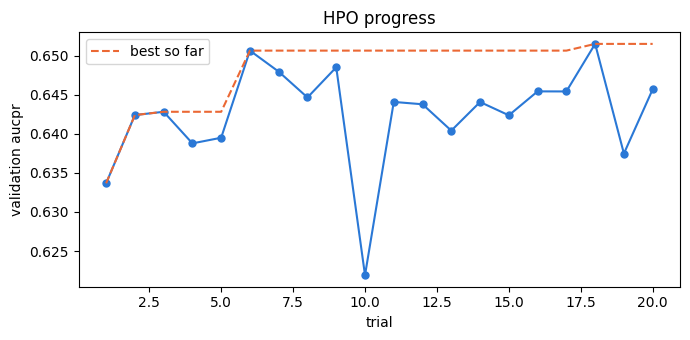

In [16]:
# Plot objective value against trial order - a rising ceiling means the Bayesian search is learning.
order = results.sort_values("TrainingStartTime")
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, len(order) + 1), order.FinalObjectiveValue, "o-", ms=5, color="#2a78d6")
plt.plot(range(1, len(order) + 1), order.FinalObjectiveValue.cummax(), "--", color="#eb6834", label="best so far")
plt.xlabel("trial"); plt.ylabel("validation aucpr"); plt.title("HPO progress"); plt.legend()
plt.tight_layout(); plt.show()

In [17]:
# Attach to the winning training job and print its hyperparameters for the report.
best = tuner.best_estimator()
best_hp = {k: v for k, v in best.hyperparameters().items() if k in ranges or k in ("num_round",)}
print("Best job :", tuner.best_training_job())
print("Best validation aucpr:", results.FinalObjectiveValue.max().round(4))
pd.Series(best_hp).to_frame("value")


2026-08-17 05:18:41 Starting - Found matching resource for reuse
2026-08-17 05:18:41 Downloading - Downloading the training image
2026-08-17 05:18:41 Training - Training image download completed. Training in progress.
2026-08-17 05:18:41 Stopping - Stopping the training job early
2026-08-17 05:18:41 Uploading - Uploading generated training model
2026-08-17 05:18:41 Stopped - Resource retained for reuse


Best job : sagemaker-xgboost-260817-0509-018-c50c3dc9
Best validation aucpr: 0.6515


,value
alpha,1.667149662345487
colsample_bytree,0.8668420704333495
eta,0.0499825389478884
gamma,0.3846090716154399
lambda,5.889769349585911
max_depth,2
min_child_weight,2.3288922800400496
num_round,500
subsample,0.7573566660180724


## 4. Model Evaluation on the Validation Set

In [18]:
# Score the validation set with Batch Transform - cheaper than an endpoint and reuses the Section 6 code path.
tf_val = best.transformer(instance_count=1, instance_type="ml.m5.large",
                          strategy="MultiRecord", assemble_with="Line", accept="text/csv",
                          output_path=f"s3://{bucket}/batch-out/val")
tf_val.transform(s3_val_feat, content_type="text/csv", split_type="Line", wait=True)
print("Predictions at:", tf_val.output_path)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: Model is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-08-17-05-19-33-725
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/transformer.py:115: SageMakerV2DeprecationWarning: Transformer is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `sagemaker.core.shapes.TransformJob`.
See https://github.com/aws/sagemaker-pyth

.................................
/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-08-17:05:25:03:INFO] No GPUs detected (normal if no gpus installed)
[2026-08-17:05:25:03:INFO] No GPUs detected (normal if no gpus installed)
[2026-08-17:05:25:03:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|

In [19]:
# Download the returned probabilities and align them with the labels we held back locally.
def fetch_preds(output_path, filename):
    key = "/".join(output_path.replace("s3://", "").split("/")[1:]) + f"/{filename}.out"
    boto3.client("s3").download_file(bucket, key, f"/tmp/{filename}.out")
    return pd.read_csv(f"/tmp/{filename}.out", header=None).iloc[:, 0].values

p_val = fetch_preds(tf_val.output_path, "val_features.csv")
assert len(p_val) == len(y_val), f"row mismatch: {len(p_val)} vs {len(y_val)}"
print(f"{len(p_val)} scores | mean {p_val.mean():.3f} | range [{p_val.min():.3f}, {p_val.max():.3f}]")

1056 scores | mean 0.430 | range [0.029, 0.909]


In [20]:
# Threshold-independent metrics first: these judge the ranking, not the cutoff.
print(f"ROC-AUC : {roc_auc_score(y_val, p_val):.4f}")
print(f"PR-AUC  : {average_precision_score(y_val, p_val):.4f}")

ROC-AUC : 0.8497
PR-AUC  : 0.6547


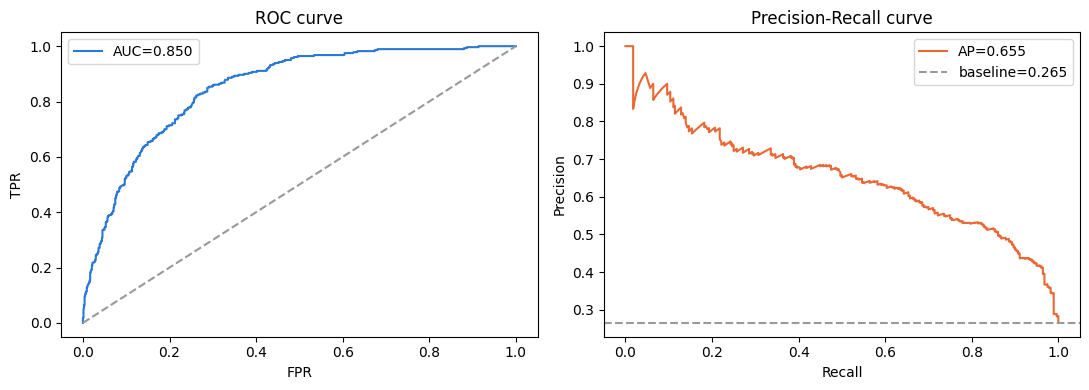

In [21]:
# Plot ROC and precision-recall curves; the PR curve is the honest one at a 26.5% positive rate.
fpr, tpr, _ = roc_curve(y_val, p_val); prec, rec, _ = precision_recall_curve(y_val, p_val)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(fpr, tpr, color="#2a78d6", label=f"AUC={roc_auc_score(y_val, p_val):.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="#999"); ax[0].set(xlabel="FPR", ylabel="TPR", title="ROC curve"); ax[0].legend()
ax[1].plot(rec, prec, color="#eb6834", label=f"AP={average_precision_score(y_val, p_val):.3f}")
ax[1].axhline(y_val.mean(), ls="--", color="#999", label=f"baseline={y_val.mean():.3f}")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve"); ax[1].legend()
plt.tight_layout(); plt.show()

In [22]:
# Sweep thresholds on the VALIDATION set to find the F1-optimal cutoff (never tune this on test).
grid = np.linspace(0.05, 0.95, 91)
sweep = pd.DataFrame({"threshold": grid,
                      "f1":        [f1_score(y_val, p_val >= t) for t in grid],
                      "precision": [precision_score(y_val, p_val >= t, zero_division=0) for t in grid],
                      "recall":    [recall_score(y_val, p_val >= t) for t in grid]})
t_f1 = sweep.loc[sweep.f1.idxmax(), "threshold"]
print(f"F1-optimal threshold = {t_f1:.2f}  (F1 = {sweep.f1.max():.4f})   vs default 0.50 F1 = {f1_score(y_val, p_val >= .5):.4f}")

F1-optimal threshold = 0.55  (F1 = 0.6435)   vs default 0.50 F1 = 0.6382


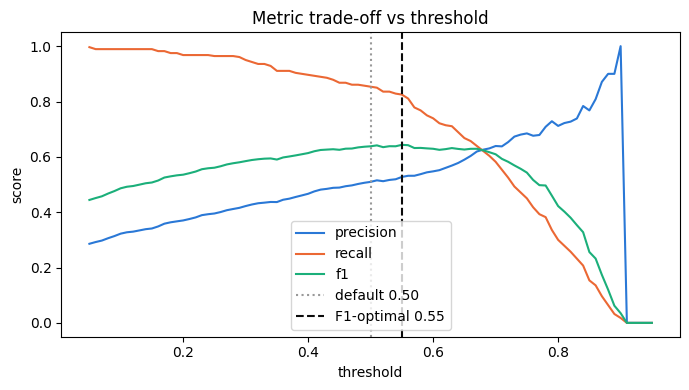

In [23]:
# Visualize how precision, recall and F1 trade off across the cutoff range.
plt.figure(figsize=(7, 4))
for col, colr in zip(["precision", "recall", "f1"], ["#2a78d6", "#eb6834", "#1baf7a"]):
    plt.plot(sweep.threshold, sweep[col], label=col, color=colr)
plt.axvline(0.5, ls=":", color="#999", label="default 0.50")
plt.axvline(t_f1, ls="--", color="#0b0b0b", label=f"F1-optimal {t_f1:.2f}")
plt.xlabel("threshold"); plt.ylabel("score"); plt.title("Metric trade-off vs threshold"); plt.legend()
plt.tight_layout(); plt.show()

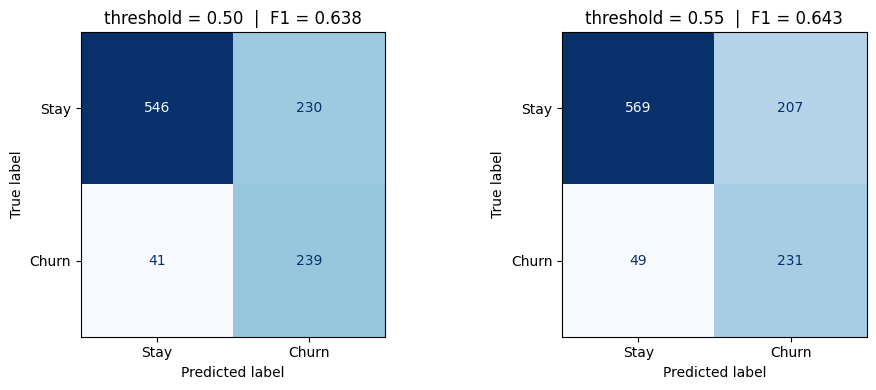

              precision    recall  f1-score   support

        Stay      0.921     0.733     0.816       776
       Churn      0.527     0.825     0.643       280

    accuracy                          0.758      1056
   macro avg      0.724     0.779     0.730      1056
weighted avg      0.816     0.758     0.771      1056



In [24]:
# Confusion matrices side by side: the default cutoff versus the F1-optimal one.
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, t in zip(ax, [0.5, t_f1]):
    ConfusionMatrixDisplay(confusion_matrix(y_val, p_val >= t),
                           display_labels=["Stay", "Churn"]).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(f"threshold = {t:.2f}  |  F1 = {f1_score(y_val, p_val >= t):.3f}")
plt.tight_layout(); plt.show()
print(classification_report(y_val, p_val >= t_f1, target_names=["Stay", "Churn"], digits=3))

## 5. Cost-Sensitive Threshold

The F1-optimal cutoff assumes precision and recall matter equally. In retention they do not: missing a
churner costs the customer's lifetime margin, while a false positive costs only a retention offer.
Edit the two constants below to match your economics and the cutoff moves accordingly.

In [25]:
# Set the business costs, then pick the threshold that minimises total expected cost on validation.
COST_FN = 500   # lost margin when a churner is missed
COST_FP = 50    # wasted retention offer on a customer who would have stayed
def total_cost(y, p, t):
    tn, fp, fn, tp = confusion_matrix(y, p >= t).ravel()
    return fp * COST_FP + fn * COST_FN
sweep["cost"] = [total_cost(y_val, p_val, t) for t in grid]
t_cost = sweep.loc[sweep.cost.idxmin(), "threshold"]
print(f"Cost-optimal threshold = {t_cost:.2f}  (cost = ${sweep.cost.min():,.0f})")
print(f"  vs default 0.50 -> ${total_cost(y_val, p_val, 0.5):,.0f}   vs F1-optimal -> ${total_cost(y_val, p_val, t_f1):,.0f}")

Cost-optimal threshold = 0.28  (cost = $24,300)
  vs default 0.50 -> $32,000   vs F1-optimal -> $34,850


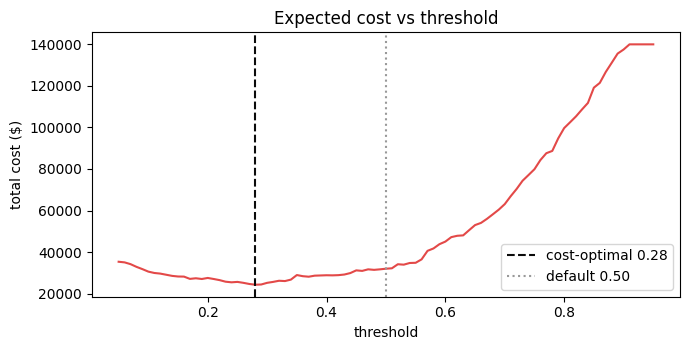

In [26]:
# Plot the cost curve so the choice of operating point is visible rather than asserted.
plt.figure(figsize=(7, 3.6))
plt.plot(sweep.threshold, sweep.cost, color="#e34948")
plt.axvline(t_cost, ls="--", color="#0b0b0b", label=f"cost-optimal {t_cost:.2f}")
plt.axvline(0.5, ls=":", color="#999", label="default 0.50")
plt.xlabel("threshold"); plt.ylabel("total cost ($)"); plt.title("Expected cost vs threshold"); plt.legend()
plt.tight_layout(); plt.show()
THRESHOLD = t_cost      # the operating point we deploy with

## 6. Batch Inference on Unseen Data

In [27]:
# Run Batch Transform over the held-out test set, which the model has never seen at any stage.
tf_test = best.transformer(instance_count=1, instance_type="ml.m5.large",
                           strategy="MultiRecord", assemble_with="Line", accept="text/csv",
                           output_path=f"s3://{bucket}/batch-out/test")
tf_test.transform(s3_batch, content_type="text/csv", split_type="Line", wait=True)
p_test = fetch_preds(tf_test.output_path, "batch_input.csv")
print(f"{len(p_test)} predictions returned")

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-08-17-05-25-28-959
INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2026-08-17-05-25-29-446


................................./miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-08-17:05:31:00:INFO] No GPUs detected (normal if no gpus installed)
[2026-08-17:05:31:00:INFO] No GPUs detected (normal if no gpus installed)
[2026-08-17:05:31:00:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|i

In [28]:
# Apply the validation-derived threshold and assemble a scored, risk-banded output table.
scored = pd.DataFrame({"churn_probability": p_test.round(4),
                       "predicted_churn":   (p_test >= THRESHOLD).astype(int),
                       "actual_churn":      y_test})
scored["risk_band"] = pd.cut(scored.churn_probability, [0, .3, .6, 1.0], labels=["Low", "Medium", "High"])
print("scored output ->", to_s3_csv(scored, f"/predictions/test_predictions.csv", header=True))
display(scored.head())
display(scored.groupby("risk_band", observed=True).agg(customers=("actual_churn", "size"),
                                                       actual_churn_rate=("actual_churn", "mean")).round(3))

scored output -> s3://churn-prediction-ak//predictions/test_predictions.csv


,churn_probability,predicted_churn,actual_churn,risk_band
0,0.5975,1,1,Medium
1,0.2424,0,0,Low
2,0.0836,0,0,Low
3,0.4148,1,0,Medium
4,0.0666,0,0,Low


,customers,actual_churn_rate
risk_band,,
Low,434,0.055
Medium,292,0.229
High,331,0.574


,test score
ROC-AUC,0.8417
PR-AUC,0.6614
F1,0.5640
Precision,0.4056
Recall,0.9253


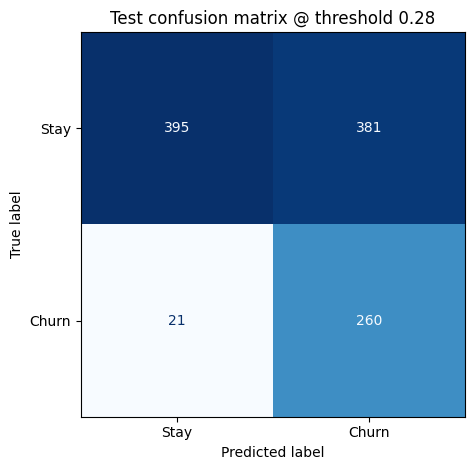

              precision    recall  f1-score   support

        Stay      0.950     0.509     0.663       776
       Churn      0.406     0.925     0.564       281

    accuracy                          0.620      1057
   macro avg      0.678     0.717     0.613      1057
weighted avg      0.805     0.620     0.636      1057



In [29]:
# Final unbiased scorecard on the test set at the deployed threshold.
final = {"ROC-AUC":   roc_auc_score(y_test, p_test),
         "PR-AUC":    average_precision_score(y_test, p_test),
         "F1":        f1_score(y_test, scored.predicted_churn),
         "Precision": precision_score(y_test, scored.predicted_churn),
         "Recall":    recall_score(y_test, scored.predicted_churn)}
display(pd.Series(final).round(4).to_frame("test score"))
ConfusionMatrixDisplay(confusion_matrix(y_test, scored.predicted_churn),
                       display_labels=["Stay", "Churn"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Test confusion matrix @ threshold {THRESHOLD:.2f}"); plt.tight_layout(); plt.show()
print(classification_report(y_test, scored.predicted_churn, target_names=["Stay", "Churn"], digits=3))

In [30]:
# Compare validation and test scores - a gap under ~0.02 means the tuning did not overfit the validation split.
compare = pd.DataFrame({
    "validation": [roc_auc_score(y_val, p_val), average_precision_score(y_val, p_val),
                   f1_score(y_val, p_val >= THRESHOLD)],
    "test":       [final["ROC-AUC"], final["PR-AUC"], final["F1"]]}, index=["ROC-AUC", "PR-AUC", "F1"])
compare["gap"] = compare.validation - compare.test
display(compare.round(4))

,validation,test,gap
ROC-AUC,0.8497,0.8417,0.0081
PR-AUC,0.6547,0.6614,-0.0067
F1,0.5769,0.5640,0.0129


## 7. Notes

- **No endpoint was created**, so there is nothing to delete and no hourly charge. Batch Transform spins the
  instance up and down per job, which is the right fit for churn scoring — you score the customer base on a
  schedule, not per request. If a live endpoint is needed later: `best.deploy(...)`, then
  `predictor.delete_endpoint()` when finished.
- **Threshold provenance matters.** It is chosen on validation and merely applied to test. Picking it on test
  would leak and inflate the reported F1.
- **Reusing a finished tuning job** instead of re-running it: `HyperparameterTuner.attach("<tuning-job-name>")`.
- **Cost control:** `ml.m5.large` is ample at 4,930 rows. Adding `use_spot_instances=True`,
  `max_wait=7200` to the estimator cuts training cost substantially for jobs this small.